In [3]:
library(readr)
library(restriktor)
library(zoo)
library(dplyr)
library(tidyr)
library(car)
library(ggplot2)
library(stargazer)
library(readxl)
library(openxlsx)
library(writexl)

In [4]:
getwd()
df <- read_csv("intermediate_data_per_hour_cze.csv", show_col_types = FALSE)

[1] "/Users/smirovaclav/Documents/decomposition/decomp_lockdown_per_hour"

# WAGE eq.

In [5]:
lag_model_wage <- df %>%
  mutate(
    d_2020Q2 = ifelse(date == "2020Q2", 1, 0), d_2021Q1 = ifelse(date == "2021Q1", 1, 0),
    gw_lag1 = lag(gw, 1), gw_lag2 = lag(gw, 2), gw_lag3 = lag(gw, 3), gw_lag4 = lag(gw, 4),
    cf1_lag1 = lag(cf1, 1), cf1_lag2 = lag(cf1, 2), cf1_lag3 = lag(cf1, 3), cf1_lag4 = lag(cf1, 4),
    diff_cpi_lag1 = lag(diff_cpi, 1), diff_cpi_lag2 = lag(diff_cpi, 2), diff_cpi_lag3 = lag(diff_cpi, 3), diff_cpi_lag4 = lag(diff_cpi, 4),
    vu_lag1 = lag(vu, 1), vu_lag2 = lag(vu, 2), vu_lag3 = lag(vu, 3), vu_lag4 = lag(vu, 4),
    gpty_lag1 = lag(gpty, 1)
  ) %>%
  select(
    date, gw, gw_lag1, gw_lag2, gw_lag3, gw_lag4,
    cf1_lag1, cf1_lag2, cf1_lag3, cf1_lag4,
    diff_cpi_lag1, diff_cpi_lag2, diff_cpi_lag3, diff_cpi_lag4,
    vu_lag1, vu_lag2, vu_lag3, vu_lag4,
    gpty_lag1,
    d_2020Q2, d_2021Q1
  ) %>%
  na.omit()
wage_model <- lm(gw ~ gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + 
                      cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 +
                      diff_cpi_lag1 + diff_cpi_lag2 + diff_cpi_lag3 + diff_cpi_lag4 +
                      vu_lag1 + vu_lag2 + vu_lag3 + vu_lag4 +
                      gpty_lag1 +
                      d_2020Q2 + d_2021Q1,
                      data = lag_model_wage)
# vertical Phillips curve in LR
my_constraints_wage <- 'gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 = 1'
wage_model_restricted <- restriktor(wage_model, 
                                    constraints = my_constraints_wage)
summary(wage_model_restricted)


Call:
conLM.lm(object = object, constraints = constraints)

Restriktor: restricted linear model:

Residuals:
      Min        1Q    Median        3Q       Max 
-12.17550  -3.12994   0.47221   3.65167  15.91184 

Coefficients:
                Estimate Std. Error t value  Pr(>|t|)    
(Intercept)    -0.612544   1.405237 -0.4359 0.6641441    
gw_lag1        -0.507395   0.124443 -4.0773 0.0001111 ***
gw_lag2        -0.020617   0.122662 -0.1681 0.8669643    
gw_lag3         0.323406   0.116189  2.7834 0.0067827 ** 
gw_lag4         0.264876   0.107256  2.4696 0.0157709 *  
cf1_lag1        0.615703   2.145188  0.2870 0.7748812    
cf1_lag2        4.669488   3.565958  1.3095 0.1943227    
cf1_lag3       -1.521847   3.588174 -0.4241 0.6726702    
cf1_lag4       -2.823614   2.635890 -1.0712 0.2874613    
diff_cpi_lag1  -1.003310   0.974570 -1.0295 0.3065149    
diff_cpi_lag2  -1.233256   1.101266 -1.1199 0.2663029    
diff_cpi_lag3   0.691493   1.100958  0.6281 0.5318323    
diff_cpi_lag4  -0.0

In [6]:
v_list_gw <- list(gw=paste0("gw_lag",1:4), cf1=paste0("cf1_lag",1:4), catch=paste0("diff_cpi_lag",1:4), vu=paste0("vu_lag",1:4), gpty="gpty_lag1")

for (n in names(v_list_gw)) {
  v <- v_list_gw[[n]]
  s <- sum(coef(wage_model_restricted)[v], na.rm=TRUE)
  res_s <- linearHypothesis(wage_model, paste(paste(v, collapse="+"), "=0"))
  ps <- res_s[2, grep("Pr\\(>", names(res_s))]  
  if(length(v)>1) {
    res_j <- linearHypothesis(wage_model, v)
    pj <- res_j[2, grep("Pr\\(>", names(res_j))]
  } else {
    pj <- summary(wage_model)$coefficients[v, 4]
  } 
  cat(sprintf("%-5s | sum: %7.4f | p-sum: %.4f | p-joint: %.4f\n", n, s, ps, pj))
}

gw    | sum:  0.0603 | p-sum: 0.8864 | p-joint: 0.0001
cf1   | sum:  0.9397 | p-sum: 0.6634 | p-joint: 0.3371
catch | sum: -1.6214 | p-sum: 0.0476 | p-joint: 0.2612
vu    | sum:  3.3586 | p-sum: 0.0681 | p-joint: 0.0204
gpty  | sum:  0.1701 | p-sum: 0.7066 | p-joint: 0.7066


### Model tested on pre-covid data

In [13]:
# --- 1) Příprava dat s filtrem ---
lag_model_wage_pre2020 <- df %>%
  # Vytvoření lagů
  mutate(
    gw_lag1 = lag(gw, 1), gw_lag2 = lag(gw, 2), gw_lag3 = lag(gw, 3), gw_lag4 = lag(gw, 4),
    cf1_lag1 = lag(cf1, 1), cf1_lag2 = lag(cf1, 2), cf1_lag3 = lag(cf1, 3), cf1_lag4 = lag(cf1, 4),
    diff_cpi_lag1 = lag(diff_cpi, 1), diff_cpi_lag2 = lag(diff_cpi, 2), 
    diff_cpi_lag3 = lag(diff_cpi, 3), diff_cpi_lag4 = lag(diff_cpi, 4),
    vu_lag1 = lag(vu, 1), vu_lag2 = lag(vu, 2), vu_lag3 = lag(vu, 3), vu_lag4 = lag(vu, 4),
    gpty_lag1 = lag(gpty, 1)
  ) %>%
  # FILTR: Pouze data do konce roku 2019
  filter(date < "2020Q1") %>% 
  na.omit()

# --- 2) Odhad standardního LM (bez dummies) ---
wage_model_pre <- lm(gw ~ gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + 
                        cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 +
                        diff_cpi_lag1 + diff_cpi_lag2 + diff_cpi_lag3 + diff_cpi_lag4 +
                        vu_lag1 + vu_lag2 + vu_lag3 + vu_lag4 +
                        gpty_lag1,
                      data = lag_model_wage_pre2020)

# --- 3) Aplikace restrikce ---
# Restrikce zůstává stejná - součet vah mezd a očekávání = 1
my_constraints_wage <- 'gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 = 1'

wage_model_restricted_pre <- restriktor(wage_model_pre, 
                                        constraints = my_constraints_wage)

summary(wage_model_restricted_pre)


Call:
conLM.lm(object = object, constraints = constraints)

Restriktor: restricted linear model:

Residuals:
      Min        1Q    Median        3Q       Max 
-11.95835  -2.80364   0.14371   3.07383  10.12032 

Coefficients:
                Estimate Std. Error t value  Pr(>|t|)    
(Intercept)    -2.067956   1.538018 -1.3446 0.1842868    
gw_lag1        -0.534009   0.139140 -3.8379 0.0003224 ***
gw_lag2        -0.192755   0.141474 -1.3625 0.1786016    
gw_lag3         0.272154   0.130368  2.0876 0.0414808 *  
gw_lag4         0.217190   0.121008  1.7948 0.0781757 .  
cf1_lag1       -0.116558   2.906018 -0.0401 0.9681514    
cf1_lag2       -0.337750   4.429375 -0.0763 0.9394951    
cf1_lag3       -0.528322   4.195822 -0.1259 0.9002574    
cf1_lag4        2.220050   3.189124  0.6961 0.4892778    
diff_cpi_lag1  -0.697855   1.190678 -0.5861 0.5602069    
diff_cpi_lag2  -0.070224   1.477726 -0.0475 0.9622698    
diff_cpi_lag3  -1.173851   1.435227 -0.8179 0.4169520    
diff_cpi_lag4  -0.7

# Price eq.

In [7]:
lag_model_price <- df %>%
  mutate( 
    d_tariff = case_when( date == "2022Q4" ~ 1, date == "2023Q1" ~ -1, TRUE ~ 0),  
    gcpi_lag1 = lag(gcpi, 1), gcpi_lag2 = lag(gcpi, 2), gcpi_lag3 = lag(gcpi, 3), gcpi_lag4 = lag(gcpi, 4),
    gw_lag1 = lag(gw, 1), gw_lag2 = lag(gw, 2), gw_lag3 = lag(gw, 3), gw_lag4 = lag(gw, 4),
    grpe_cpi_lag1 = lag(grpe_cpi, 1), grpe_cpi_lag2 = lag(grpe_cpi, 2), grpe_cpi_lag3 = lag(grpe_cpi, 3), grpe_cpi_lag4 = lag(grpe_cpi, 4),
    grpf_cpi_lag1 = lag(grpf_cpi, 1), grpf_cpi_lag2 = lag(grpf_cpi, 2), grpf_cpi_lag3 = lag(grpf_cpi, 3), grpf_cpi_lag4 = lag(grpf_cpi, 4),
    shortage_lag1 = lag(shortage, 1), shortage_lag2 = lag(shortage, 2), shortage_lag3 = lag(shortage, 3), shortage_lag4 = lag(shortage, 4),  
    gpty_lag1 = lag(gpty, 1)
  ) %>%
  na.omit()
price_model <- lm(gcpi ~ gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4 +
                      gw + gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + 
                      grpe_cpi +grpe_cpi_lag1 + grpe_cpi_lag2 + grpe_cpi_lag3 + grpe_cpi_lag4 +
                      grpf_cpi + grpf_cpi_lag1 + grpf_cpi_lag2 + grpf_cpi_lag3 + grpf_cpi_lag4 +
                      shortage + shortage_lag1 + shortage_lag2 + shortage_lag3 + shortage_lag4 +
                      gpty_lag1 + 
                      d_tariff,
                      data = lag_model_price)
# long-run price homogeneity
my_constraints_price <- 'gw + gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4 = 1'
price_model_restricted <- restriktor(price_model, 
                                    constraints = my_constraints_price)
summary(price_model_restricted)


Call:
conLM.lm(object = object, constraints = constraints)

Restriktor: restricted linear model:

Residuals:
     Min       1Q   Median       3Q      Max 
-3.49219 -0.80379  0.05558  0.83261  3.23785 

Coefficients:
                Estimate Std. Error t value  Pr(>|t|)    
(Intercept)   -0.1990171  0.3000383 -0.6633   0.50934    
gcpi_lag1      0.2330324  0.1040028  2.2406   0.02827 *  
gcpi_lag2      0.0625801  0.1271755  0.4921   0.62423    
gcpi_lag3      0.0851671  0.1100302  0.7740   0.44156    
gcpi_lag4      0.6462841  0.1165526  5.5450 5.034e-07 ***
gw             0.5323299  0.0543212  9.7997 1.067e-14 ***
gw_lag1       -0.0770650  0.0740706 -1.0404   0.30177    
gw_lag2       -0.0319295  0.0822673 -0.3881   0.69912    
gw_lag3       -0.0646438  0.0690404 -0.9363   0.35238    
gw_lag4       -0.3857554  0.0667382 -5.7801 1.976e-07 ***
grpe_cpi       0.3092983  0.0388555  7.9602 2.364e-11 ***
grpe_cpi_lag1 -0.0506710  0.0403800 -1.2549   0.21377    
grpe_cpi_lag2 -0.0077761  0.0

In [8]:
v_list_cpi <- list(
  cpi  = paste0("gcpi_lag", 1:4), gw = c("gw", paste0("gw_lag", 1:4)), grpe = c("grpe_cpi", paste0("grpe_cpi_lag", 1:4)),
  grpf = c("grpf_cpi", paste0("grpf_cpi_lag", 1:4)), shrt = c("shortage", paste0("shortage_lag", 1:4)), gpty = "gpty_lag1"
)
for (n in names(v_list_cpi)) {
  v <- v_list_cpi[[n]]
  s <- sum(coef(price_model_restricted)[v], na.rm=TRUE)
  res_s <- linearHypothesis(price_model, paste(paste(v, collapse="+"), "=0"))
  ps <- res_s[2, grep("Pr\\(>", names(res_s))]
  if(length(v) > 1) {
    res_j <- linearHypothesis(price_model, v)
    pj <- res_j[2, grep("Pr\\(>", names(res_j))]
  } else {
    pj <- summary(price_model)$coefficients[v, 4]
  }
  cat(sprintf("%-5s | sum: %7.4f | p-sum: %.4f | p-joint: %.4f\n", n, s, ps, pj))
}

cpi   | sum:  1.0271 | p-sum: 0.0994 | p-joint: 0.0095
gw    | sum: -0.0271 | p-sum: 0.3232 | p-joint: 0.0000
grpe  | sum: -0.0128 | p-sum: 0.1206 | p-joint: 0.0000
grpf  | sum: -0.0458 | p-sum: 0.5969 | p-joint: 0.0000
shrt  | sum:  0.1165 | p-sum: 0.0012 | p-joint: 0.0086
gpty  | sum:  0.0337 | p-sum: 0.7358 | p-joint: 0.7358


# Short-Term Inflation Expectation

In [9]:
lag_model_cf1 <- df %>%
  mutate(
    cf1_lag1 = lag(cf1, 1), cf1_lag2 = lag(cf1, 2), cf1_lag3 = lag(cf1, 3), cf1_lag4 = lag(cf1, 4),
    cf3_lag1 = lag(cf3, 1), cf3_lag2 = lag(cf3, 2), cf3_lag3 = lag(cf3, 3), cf3_lag4 = lag(cf3, 4),
    gcpi_lag1 = lag(gcpi, 1), gcpi_lag2 = lag(gcpi, 2), gcpi_lag3 = lag(gcpi, 3), gcpi_lag4 = lag(gcpi, 4),
 ) %>%
    na.omit()
cf1_model <- lm(cf1 ~ cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 +
                      cf3 + cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 +
                      gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4,
                      data = lag_model_cf1)
# vertical Phillips curve in LR
my_constraints_cf1 <- 'cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 + cf3 + cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 + 
                       gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4 == 1'
cf1_model_restricted <- restriktor(cf1_model, 
                                    constraints = my_constraints_cf1)
summary(cf1_model_restricted)


Call:
conLM.lm(object = object, constraints = constraints)

Restriktor: restricted linear model:

Residuals:
      Min        1Q    Median        3Q       Max 
-0.895625 -0.151444  0.036018  0.137159  0.938720 

Coefficients:
              Estimate Std. Error t value  Pr(>|t|)    
(Intercept)  0.0563103  0.0361123  1.5593   0.12282    
cf1_lag1     0.9274639  0.1143217  8.1128 4.504e-12 ***
cf1_lag2    -0.0665370  0.1481441 -0.4491   0.65453    
cf1_lag3    -0.0368208  0.1427608 -0.2579   0.79712    
cf1_lag4     0.0266916  0.0822147  0.3247   0.74628    
cf3          0.3006625  0.2924434  1.0281   0.30696    
cf3_lag1     0.2701917  0.3693977  0.7314   0.46662    
cf3_lag2    -0.6647886  0.3472125 -1.9146   0.05907 .  
cf3_lag3     0.1561256  0.3177401  0.4914   0.62450    
cf3_lag4     0.0110998  0.2598049  0.0427   0.96603    
gcpi         0.0795050  0.0099641  7.9792 8.257e-12 ***
gcpi_lag1    0.0553151  0.0118852  4.6541 1.254e-05 ***
gcpi_lag2    0.0100192  0.0133122  0.7526   0

In [10]:
v_list_cf1 <- list(
  cf1 = paste0("cf1_lag", 1:4),
  cf3 = c("cf3", paste0("cf3_lag", 1:4)), 
  gcpi = c("gcpi", paste0("gcpi_lag", 1:4))       
)
for (n in names(v_list_cf1)) {
  v <- v_list_cf1[[n]]
  s <- sum(coef(cf1_model_restricted)[v], na.rm=TRUE)
  res_s <- linearHypothesis(cf1_model, paste(paste(v, collapse="+"), "=0"))
  ps <- res_s[2, grep("Pr\\(>", names(res_s))]  
  res_j <- linearHypothesis(cf1_model, v)
  pj <- res_j[2, grep("Pr\\(>", names(res_j))]
  cat(sprintf("%-5s | sum: %7.4f | p-sum: %.4f | p-joint: %.4f\n", n, s, ps, pj))
}

cf1   | sum:  0.8508 | p-sum: 0.0000 | p-joint: 0.0000
cf3   | sum:  0.0733 | p-sum: 0.2717 | p-joint: 0.3496
gcpi  | sum:  0.0759 | p-sum: 0.0366 | p-joint: 0.0000


# Long-Term Inflation Expectation

In [11]:
lag_model_cf3 <- df %>%
  mutate(

    cf3_lag1 = lag(cf3, 1), cf3_lag2 = lag(cf3, 2), cf3_lag3 = lag(cf3, 3), cf3_lag4 = lag(cf3, 4),
    gcpi_lag1 = lag(gcpi, 1), gcpi_lag2 = lag(gcpi, 2), gcpi_lag3 = lag(gcpi, 3), gcpi_lag4 = lag(gcpi, 4),
  ) %>%
  na.omit()
cf3_model <- lm(cf3 ~ cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 +
                      gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4,
                      data = lag_model_cf3)
# vertical Phillips curve in LR
my_constraints_cf3 <- 'cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 + 
                       gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4= 1'
cf3_model_restricted <- restriktor(cf3_model, 
                                    constraints = my_constraints_cf3)
summary(cf3_model_restricted)


Call:
conLM.lm(object = object, constraints = constraints)

Restriktor: restricted linear model:

Residuals:
      Min        1Q    Median        3Q       Max 
-0.260838 -0.067856  0.013253  0.059945  0.322555 

Coefficients:
              Estimate Std. Error t value  Pr(>|t|)    
(Intercept) -0.0225151  0.0116500 -1.9326  0.056573 .  
cf3_lag1     0.8540041  0.1005913  8.4898 5.374e-13 ***
cf3_lag2     0.0311649  0.1297959  0.2401  0.810819    
cf3_lag3     0.0508368  0.1100821  0.4618  0.645385    
cf3_lag4     0.0575941  0.0861855  0.6683  0.505759    
gcpi         0.0063958  0.0030892  2.0704  0.041416 *  
gcpi_lag1    0.0084085  0.0031219  2.6934  0.008503 ** 
gcpi_lag2    0.0051753  0.0032981  1.5692  0.120277    
gcpi_lag3   -0.0041250  0.0031541 -1.3078  0.194412    
gcpi_lag4   -0.0094544  0.0030973 -3.0525  0.003019 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.10456 on 86 degrees of freedom
Standard errors: standard 
Mult

In [13]:
v_list_cf3 <- list(
  cf3 = paste0("cf3_lag", 1:4),
  gcpi   = c("gcpi", paste0("gcpi_lag", 1:4))
)
for (n in names(v_list_cf3)) {
  v <- v_list_cf3[[n]]
  s <- sum(coef(cf3_model_restricted)[v], na.rm=TRUE)
  res_s <- linearHypothesis(cf3_model, paste(paste(v, collapse="+"), "=0"))
  ps <- res_s[2, grep("Pr\\(>", names(res_s))]    
  res_j <- linearHypothesis(cf3_model, v)
  pj <- res_j[2, grep("Pr\\(>", names(res_j))] 
  cat(sprintf("%-11s | sum: %7.4f | p-sum: %.4f | p-joint: %.4f\n", n, s, ps, pj))
}

cf3         | sum:  0.9936 | p-sum: 0.0000 | p-joint: 0.0000
gcpi        | sum:  0.0064 | p-sum: 0.0369 | p-joint: 0.0002


# Chow test

### Predictive chow test – wage eq.

In [20]:
df_pre  <- subset(lag_model_wage, date <= "2019Q4")
df_post <- subset(lag_model_wage, date >= "2020Q1")

obs_precovid  <- nrow(df_pre)
obs_postcovid <- nrow(df_post)

formula_chow <- gw ~ gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + 
                     cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 +
                     diff_cpi_lag1 + diff_cpi_lag2 + diff_cpi_lag3 + diff_cpi_lag4 +
                     vu_lag1 + vu_lag2 + vu_lag3 + vu_lag4 +
                     gpty_lag1

constraint_chow <- 'gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 + cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 = 1'

model_full <- lm(formula_chow, data = lag_model_wage)
rest_full  <- restriktor(model_full, constraints = constraint_chow)
rss_full   <- sum(residuals(rest_full)^2) 

model_pre <- lm(formula_chow, data = df_pre)
rest_pre  <- restriktor(model_pre, constraints = constraint_chow)
rss_pre   <- sum(residuals(rest_pre)^2)

par_full <- length(coef(model_full)) - 1


df1 <- obs_postcovid                  # numerator df
df2 <- obs_precovid - par_full        # denominator df

# F-statistics
F_stat <- ((rss_full - rss_pre) / df1) / (rss_pre / df2)

# critical values
crit_value_10 <- qf(0.10, df1, df2, lower.tail = FALSE)
crit_value_5  <- qf(0.05, df1, df2, lower.tail = FALSE)
crit_value_1  <- qf(0.01, df1, df2, lower.tail = FALSE)

# P-value
p_value <- pf(F_stat, df1, df2, lower.tail = FALSE)

chow_export_wage <- data.frame(
  `F test` = F_stat,
  `degrees of freedom postcovid obs` = df1,
  `degrees of freedom (precovid obs minus parameters)` = df2,
  `critical value 10%` = crit_value_10,
  `critical value 5%` = crit_value_5,
  `critical value 1%` = crit_value_1,
  `p-value` = p_value,
  check.names = FALSE 
)

chow_export_wage

F test,degrees of freedom postcovid obs,degrees of freedom (precovid obs minus parameters),critical value 10%,critical value 5%,critical value 1%,p-value
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2.228252,23,56,1.52702,1.723872,2.157761,0.007660811


### Predictive chow test – price eq.

In [21]:
df_pre  <- subset(lag_model_price, date <= "2019Q4")
df_post <- subset(lag_model_price, date >= "2020Q1")

obs_precovid  <- nrow(df_pre)
obs_postcovid <- nrow(df_post)

formula_chow <- gcpi ~ gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4 +
                       gw + gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 +
                       grpe_cpi + grpe_cpi_lag1 + grpe_cpi_lag2 + grpe_cpi_lag3 + grpe_cpi_lag4 +
                       grpf_cpi + grpf_cpi_lag1 + grpf_cpi_lag2 + grpf_cpi_lag3 + grpf_cpi_lag4 +
                       shortage + shortage_lag1 + shortage_lag2 + shortage_lag3 + shortage_lag4 +
                       gpty_lag1

constraint_chow <- 'gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4 + gw + gw_lag1 + gw_lag2 + gw_lag3 + gw_lag4 = 1'

model_full <- lm(formula_chow, data = lag_model_price)
rest_full  <- restriktor(model_full, constraints = constraint_chow)
rss_full   <- sum(residuals(rest_full)^2) 

model_pre <- lm(formula_chow, data = df_pre)
rest_pre  <- restriktor(model_pre, constraints = constraint_chow)
rss_pre   <- sum(residuals(rest_pre)^2)

par_full <- length(coef(model_full)) - 1


df1 <- obs_postcovid                  # numerator df
df2 <- obs_precovid - par_full        # denominator df

# F-statistics
F_stat <- ((rss_full - rss_pre) / df1) / (rss_pre / df2)

# critical values
crit_value_10 <- qf(0.10, df1, df2, lower.tail = FALSE)
crit_value_5  <- qf(0.05, df1, df2, lower.tail = FALSE)
crit_value_1  <- qf(0.01, df1, df2, lower.tail = FALSE)

# P-value
p_value <- pf(F_stat, df1, df2, lower.tail = FALSE)

chow_export_price <- data.frame(
  `F test` = F_stat,
  `degrees of freedom postcovid obs` = df1,
  `degrees of freedom (precovid obs minus parameters)` = df2,
  `critical value 10%` = crit_value_10,
  `critical value 5%` = crit_value_5,
  `critical value 1%` = crit_value_1,
  `p-value` = p_value,
  check.names = FALSE 
)

chow_export_price

F test,degrees of freedom postcovid obs,degrees of freedom (precovid obs minus parameters),critical value 10%,critical value 5%,critical value 1%,p-value
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2.066228,23,48,1.549503,1.756759,2.218763,0.01709389


### Predictive chow test – ST inflation expe.  eq.

In [22]:
df_pre  <- subset(lag_model_cf1, date <= "2019Q4")
df_post <- subset(lag_model_cf1, date >= "2020Q1")

obs_precovid  <- nrow(df_pre)
obs_postcovid <- nrow(df_post)

formula_chow <- cf1 ~ cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 +
                      cf3 + cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 +
                      gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4

constraint_chow <- 'cf1_lag1 + cf1_lag2 + cf1_lag3 + cf1_lag4 + cf3 + cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 + gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4 = 1'

model_full <- lm(formula_chow, data = lag_model_cf1)
rest_full  <- restriktor(model_full, constraints = constraint_chow)
rss_full   <- sum(residuals(rest_full)^2) 

model_pre <- lm(formula_chow, data = df_pre)
rest_pre  <- restriktor(model_pre, constraints = constraint_chow)
rss_pre   <- sum(residuals(rest_pre)^2)

par_full <- length(coef(model_full)) - 1


df1 <- obs_postcovid                  # numerator df
df2 <- obs_precovid - par_full        # denominator df

# F-statistics
F_stat <- ((rss_full - rss_pre) / df1) / (rss_pre / df2)

# critical values
crit_value_10 <- qf(0.10, df1, df2, lower.tail = FALSE)
crit_value_5  <- qf(0.05, df1, df2, lower.tail = FALSE)
crit_value_1  <- qf(0.01, df1, df2, lower.tail = FALSE)

# P-value
p_value <- pf(F_stat, df1, df2, lower.tail = FALSE)

chow_export_cf1 <- data.frame(
  `F test` = F_stat,
  `degrees of freedom postcovid obs` = df1,
  `degrees of freedom (precovid obs minus parameters)` = df2,
  `critical value 10%` = crit_value_10,
  `critical value 5%` = crit_value_5,
  `critical value 1%` = crit_value_1,
  `p-value` = p_value,
  check.names = FALSE 
)

chow_export_cf1

F test,degrees of freedom postcovid obs,degrees of freedom (precovid obs minus parameters),critical value 10%,critical value 5%,critical value 1%,p-value
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3.189692,23,59,1.520163,1.713873,2.139345,0.0001752717


### Predictive chow test – LT inflation expe. eq.

In [23]:
df_pre  <- subset(lag_model_cf3, date <= "2019Q4")
df_post <- subset(lag_model_cf3, date >= "2020Q1")

obs_precovid  <- nrow(df_pre)
obs_postcovid <- nrow(df_post)

# Formula pro dlouhodobá očekávání (3letá)
formula_chow <- cf3 ~ cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 +
                      gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4

# Omezující podmínka (vertikální Phillipsova křivka)
constraint_chow <- 'cf3_lag1 + cf3_lag2 + cf3_lag3 + cf3_lag4 + gcpi + gcpi_lag1 + gcpi_lag2 + gcpi_lag3 + gcpi_lag4 = 1'

# 1. full sample
model_full <- lm(formula_chow, data = lag_model_cf3)
rest_full  <- restriktor(model_full, constraints = constraint_chow)
rss_full   <- sum(residuals(rest_full)^2) 

# 2. pre-covid sample
model_pre <- lm(formula_chow, data = df_pre)
rest_pre  <- restriktor(model_pre, constraints = constraint_chow)
rss_pre   <- sum(residuals(rest_pre)^2)

par_full <- length(coef(model_full)) - 1


df1 <- obs_postcovid                  # numerator df
df2 <- obs_precovid - par_full        # denominator df

# F-statistics
F_stat <- ((rss_full - rss_pre) / df1) / (rss_pre / df2)

# critical values
crit_value_10 <- qf(0.10, df1, df2, lower.tail = FALSE)
crit_value_5  <- qf(0.05, df1, df2, lower.tail = FALSE)
crit_value_1  <- qf(0.01, df1, df2, lower.tail = FALSE)

# P-value
p_value <- pf(F_stat, df1, df2, lower.tail = FALSE)

# Export tabulky (replikace Stata formátu)
chow_export_cf3 <- data.frame(
  `F test` = F_stat,
  `degrees of freedom postcovid obs` = df1,
  `degrees of freedom (precovid obs minus parameters)` = df2,
  `critical value 10%` = crit_value_10,
  `critical value 5%` = crit_value_5,
  `critical value 1%` = crit_value_1,
  `p-value` = p_value,
  check.names = FALSE 
)

chow_export_cf3

F test,degrees of freedom postcovid obs,degrees of freedom (precovid obs minus parameters),critical value 10%,critical value 5%,critical value 1%,p-value
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.5423897,23,64,1.510163,1.699318,2.112646,0.9478254


# IRF

In [16]:
gw_beta <- read_excel("eq_coefficients.xlsx", sheet = "gw")
gcpi_beta <- read_excel("eq_coefficients.xlsx", sheet = "gcpi")
cf1_beta <- read_excel("eq_coefficients.xlsx", sheet = "cf1")
cf10_beta <- read_excel("eq_coefficients.xlsx", sheet = "cf10")

# SD of residuals
sd_gw_res   <- sd(residuals(wage_model_restricted), na.rm = TRUE)
sd_gcpi_res <- sd(residuals(price_model_restricted), na.rm = TRUE)
sd_cf1_res  <- sd(residuals(cf1_model_restricted), na.rm = TRUE)
sd_cf10_res <- sd(residuals(cf3_model_restricted), na.rm = TRUE)

# Shocks (standard deviation duting Recent Great Inflation)
df_sub <- df[df$date >= "2020 Q1" & df$date <= "2023 Q3", ]
sd_energy <- sd(df_sub$grpe_hicp, na.rm = TRUE)
sd_food   <- sd(df_sub$grpf_hicp, na.rm = TRUE)
sd_short  <- sd(df_sub$shortage,  na.rm = TRUE)
sd_gpty   <- sd(df_sub$gpty,      na.rm = TRUE)
sd_vu     <- sd(df_sub$vu,        na.rm = TRUE)


results_list <- list()

for (option in 1:10) {
  
  # --- logic of shocks---
  add_grpe_shock     <- FALSE; add_grpf_shock     <- FALSE; add_vu_shock       <- FALSE
  add_shortage_shock <- FALSE; add_gw_shock       <- FALSE; add_gcpi_shock     <- FALSE
  add_cf1_shock      <- FALSE; add_cf10_shock     <- FALSE; add_gpty_shock     <- FALSE
  
  if (option == 2) add_grpe_shock <- TRUE
  else if (option == 3) add_grpf_shock <- TRUE
  else if (option == 4) add_vu_shock <- TRUE
  else if (option == 5) add_shortage_shock <- TRUE
  else if (option == 6) add_gw_shock <- TRUE
  else if (option == 7) add_gcpi_shock <- TRUE
  else if (option == 8) add_cf1_shock <- TRUE
  else if (option == 9) add_cf10_shock <- TRUE
  else if (option == 10) add_gpty_shock <- TRUE
  
  # name of results
  sh_list <- c()
  if(add_grpe_shock) sh_list <- c(sh_list, "grpe")
  if(add_grpf_shock) sh_list <- c(sh_list, "grpf")
  if(add_vu_shock) sh_list <- c(sh_list, "vu")
  if(add_shortage_shock) sh_list <- c(sh_list, "shortage")
  if(add_gw_shock) sh_list <- c(sh_list, "gw")
  if(add_gcpi_shock) sh_list <- c(sh_list, "gcpi")
  if(add_cf1_shock) sh_list <- c(sh_list, "cf1")
  if(add_cf10_shock) sh_list <- c(sh_list, "cf10")
  if(add_gpty_shock) sh_list <- c(sh_list, "gpty")
  shocks_added_text <- paste(sh_list, collapse = "_")
  if(shocks_added_text == "") shocks_added_text <- "no_shocks_added"

  # --- Inicialization of vectors ---
  timesteps <- 32
  gw_simul <- numeric(timesteps)
  gcpi_simul <- numeric(timesteps)
  cf1_simul <- numeric(timesteps)
  cf10_simul <- numeric(timesteps)
  diffcpicf_simul <- numeric(timesteps)
  grpe_shock_series <- numeric(timesteps)
  grpf_shock_series <- numeric(timesteps)
  vu_shock_series <- numeric(timesteps)
  shortage_shock_series <- numeric(timesteps)
  magpty <- numeric(timesteps) 
  
  # Persistence
  rho_grpe <- 0.0; rho_grpf <- 0.0; rho_vu <- 1.0; rho_shortage <- 0.0
  rho_gw <- 0.0; rho_gcpi <- 0.0; rho_cf1 <- 0.0; rho_cf10 <- 0.0; rho_gpty <- 0.0

  for (t in 5:timesteps) {
    
    # 1. Reset of shocks
    s_grpe <- 0; s_grpf <- 0; s_vu <- 0; s_shortage <- 0
    s_gw <- 0; s_gcpi <- 0; s_cf1 <- 0; s_cf10 <- 0; s_gpty <- 0

    # 2. shocks
    if (t == 5) {
      if (add_grpe_shock)     s_grpe     <- sd_energy
      if (add_grpf_shock)     s_grpf     <- sd_food
      if (add_vu_shock)       s_vu       <- sd_vu
      if (add_shortage_shock) s_shortage <- sd_short
      if (add_gw_shock)       s_gw       <- sd_gw_res
      if (add_gcpi_shock)     s_gcpi     <- sd_gcpi_res
      if (add_cf1_shock)      s_cf1      <- sd_cf1_res
      if (add_cf10_shock)     s_cf10     <- sd_cf10_res
      if (add_gpty_shock)     s_gpty     <- sd_gpty
    }

    # 3. (Persistence)
    grpe_shock_series[t]     <- rho_grpe * grpe_shock_series[t-1] + s_grpe
    grpf_shock_series[t]     <- rho_grpf * grpf_shock_series[t-1] + s_grpf
    vu_shock_series[t]       <- rho_vu   * vu_shock_series[t-1]   + s_vu
    shortage_shock_series[t] <- rho_shortage * shortage_shock_series[t-1] + s_shortage
    magpty[t]                <- rho_gpty * magpty[t-1] + s_gpty
    
    
    # A. (gw)
    if (add_gw_shock && t == 5) {
        gw_simul[t] <- rho_gw * gw_simul[t-1] + s_gw
    } else {
        gw_simul[t] <- gw_beta$beta[1]*gw_simul[t-1] + gw_beta$beta[2]*gw_simul[t-2] +
                       gw_beta$beta[3]*gw_simul[t-3] + gw_beta$beta[4]*gw_simul[t-4] +
                       gw_beta$beta[5]*cf1_simul[t-1] + gw_beta$beta[6]*cf1_simul[t-2] +
                       gw_beta$beta[7]*cf1_simul[t-3] + gw_beta$beta[8]*cf1_simul[t-4] +
                       gw_beta$beta[9]*magpty[t-1] + 
                       gw_beta$beta[10]*vu_shock_series[t-1] + gw_beta$beta[11]*vu_shock_series[t-2] +
                       gw_beta$beta[12]*vu_shock_series[t-3] + gw_beta$beta[13]*vu_shock_series[t-4] +
                       gw_beta$beta[14]*diffcpicf_simul[t-1] + gw_beta$beta[15]*diffcpicf_simul[t-2] +
                       gw_beta$beta[16]*diffcpicf_simul[t-3] + gw_beta$beta[17]*diffcpicf_simul[t-4]
    }

    # B. (gcpi)
    if (add_gcpi_shock && t == 5) {
        gcpi_simul[t] <- rho_gcpi * gcpi_simul[t-1] + s_gcpi
    } else {
        gcpi_simul[t] <- gcpi_beta$beta[1]*magpty[t] +
                         gcpi_beta$beta[2]*gcpi_simul[t-1] + gcpi_beta$beta[3]*gcpi_simul[t-2] +
                         gcpi_beta$beta[4]*gcpi_simul[t-3] + gcpi_beta$beta[5]*gcpi_simul[t-4] +
                         gcpi_beta$beta[6]*gw_simul[t] + gcpi_beta$beta[7]*gw_simul[t-1] +
                         gcpi_beta$beta[8]*gw_simul[t-2] + gcpi_beta$beta[9]*gw_simul[t-3] + gcpi_beta$beta[10]*gw_simul[t-4] +
                         gcpi_beta$beta[11]*grpe_shock_series[t] + gcpi_beta$beta[12]*grpe_shock_series[t-1] +
                         gcpi_beta$beta[13]*grpe_shock_series[t-2] + gcpi_beta$beta[14]*grpe_shock_series[t-3] + gcpi_beta$beta[15]*grpe_shock_series[t-4] +
                         gcpi_beta$beta[16]*grpf_shock_series[t] + gcpi_beta$beta[17]*grpf_shock_series[t-1] +
                         gcpi_beta$beta[18]*grpf_shock_series[t-2] + gcpi_beta$beta[19]*grpf_shock_series[t-3] + gcpi_beta$beta[20]*grpf_shock_series[t-4] +
                         gcpi_beta$beta[21]*shortage_shock_series[t] + gcpi_beta$beta[22]*shortage_shock_series[t-1] +
                         gcpi_beta$beta[23]*shortage_shock_series[t-2] + gcpi_beta$beta[24]*shortage_shock_series[t-3] +
                         gcpi_beta$beta[25]*shortage_shock_series[t-4]
    }

    # C. CATCH-UP
    diffcpicf_simul[t] <- 0.25 * (gcpi_simul[t] + gcpi_simul[t-1] + gcpi_simul[t-2] + gcpi_simul[t-3]) - cf1_simul[t-4]

    # D. (cf10)
    if (add_cf10_shock && t == 5) {
        cf10_simul[t] <- rho_cf10 * cf10_simul[t-1] + s_cf10
    } else {
        cf10_simul[t] <- cf10_beta$beta[1]*cf10_simul[t-1] + cf10_beta$beta[2]*cf10_simul[t-2] +
                         cf10_beta$beta[3]*cf10_simul[t-3] + cf10_beta$beta[4]*cf10_simul[t-4] +
                         cf10_beta$beta[5]*gcpi_simul[t] + cf10_beta$beta[6]*gcpi_simul[t-1] +
                         cf10_beta$beta[7]*gcpi_simul[t-2] + cf10_beta$beta[8]*gcpi_simul[t-3] + cf10_beta$beta[9]*gcpi_simul[t-4]
    }

    # E. (cf1)
    if (add_cf1_shock && t == 5) {
        cf1_simul[t] <- rho_cf1 * cf1_simul[t-1] + s_cf1
    } else {
        cf1_simul[t] <- cf1_beta$beta[1]*cf1_simul[t-1] + cf1_beta$beta[2]*cf1_simul[t-2] +
                        cf1_beta$beta[3]*cf1_simul[t-3] + cf1_beta$beta[4]*cf1_simul[t-4] +
                        cf1_beta$beta[5]*cf10_simul[t] + cf1_beta$beta[6]*cf10_simul[t-1] +
                        cf1_beta$beta[7]*cf10_simul[t-2] + cf1_beta$beta[8]*cf10_simul[t-3] + cf1_beta$beta[9]*cf10_simul[t-4] +
                        cf1_beta$beta[10]*gcpi_simul[t] + cf1_beta$beta[11]*gcpi_simul[t-1] +
                        cf1_beta$beta[12]*gcpi_simul[t-2] + cf1_beta$beta[13]*gcpi_simul[t-3] + cf1_beta$beta[14]*gcpi_simul[t-4]
    }
  }
  
  # --- results ---
  results_list[[shocks_added_text]] <- list(
    gw = gw_simul,
    gcpi = gcpi_simul,
    cf1 = cf1_simul,
    cf10 = cf10_simul
  )

} 

New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`


# IRF Inflation 

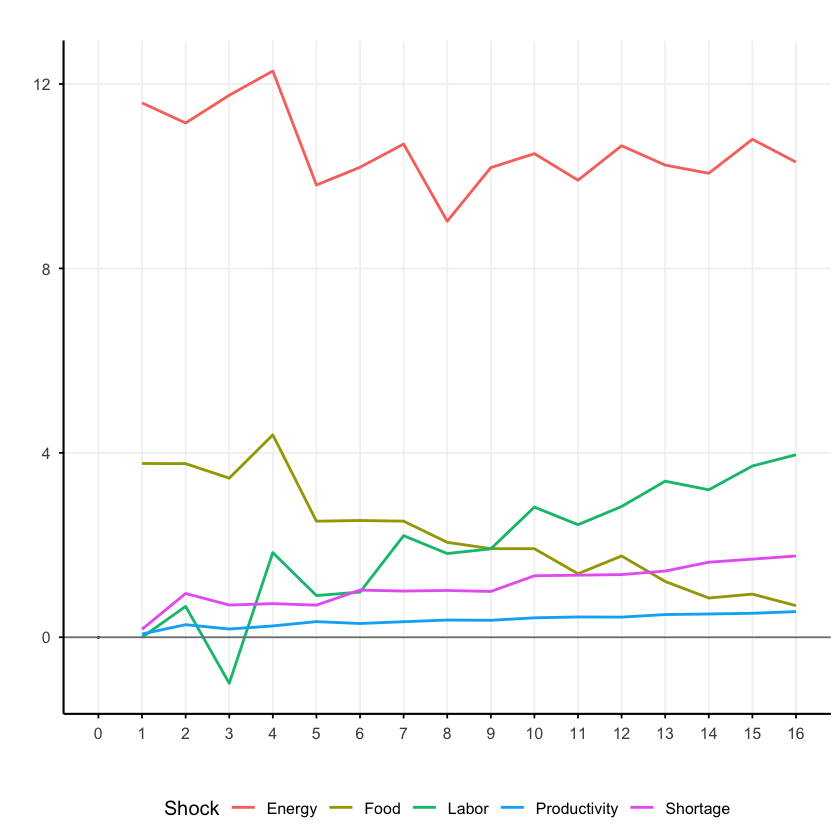

In [17]:
# 1. Příprava dat (včetně produktivity)
plot_data_raw <- data.frame(period = 1:32)

plot_data_raw$Energy       <- cumsum(results_list$grpe$gcpi)
plot_data_raw$Food         <- cumsum(results_list$grpf$gcpi)
plot_data_raw$Labor        <- cumsum(results_list$vu$gcpi)
plot_data_raw$Shortage     <- cumsum(results_list$shortage$gcpi)
plot_data_raw$Productivity <- cumsum(results_list$gpty$gcpi)

# 2. Úprava tabulky a posun osy X (Lag 4 = 0)
plot_long_raw <- plot_data_raw %>%
  mutate(x_axis = period - 4) %>%
  pivot_longer(cols = c(Energy, Food, Labor, Shortage, Productivity), 
               names_to = "Shock", 
               values_to = "Value") %>%
  filter(x_axis >= 0 & x_axis <= 16)

# 3. Vykreslení
p_gcpi <- ggplot(plot_long_raw, aes(x = x_axis, y = Value, color = Shock)) +
  # Čára začíná od bodu 1 (Lag 5 - moment nárazu)
  geom_line(data = filter(plot_long_raw, x_axis >= 1), size = 0.8) +
  
  # Bod 0,0 (Lag 4 - klid před bouří)
  geom_point(data = filter(plot_long_raw, x_axis == 0), color = "black", size = 0) +
  
  # Nulová linka
  geom_hline(yintercept = 0, color = "gray50") +
  
  scale_x_continuous(breaks = 0:16) +
  
  labs(
    title = "",
    x = "",
    y = ""
  ) +
    theme_minimal() + 
    theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "gray95"),
    
    axis.line = element_line(color = "black", linewidth = 0.6), 
    axis.ticks = element_line(color = "black"),
    
    panel.border = element_blank(),
    panel.background = element_blank(),
    
    text = element_text(size = 12)
  )
p_gcpi
ggsave("irf_price_cumulative.pdf", plot = p_gcpi, device = "pdf", 
       width = 8, height = 5, units = "in", dpi = 300)

# IRF Wage growth

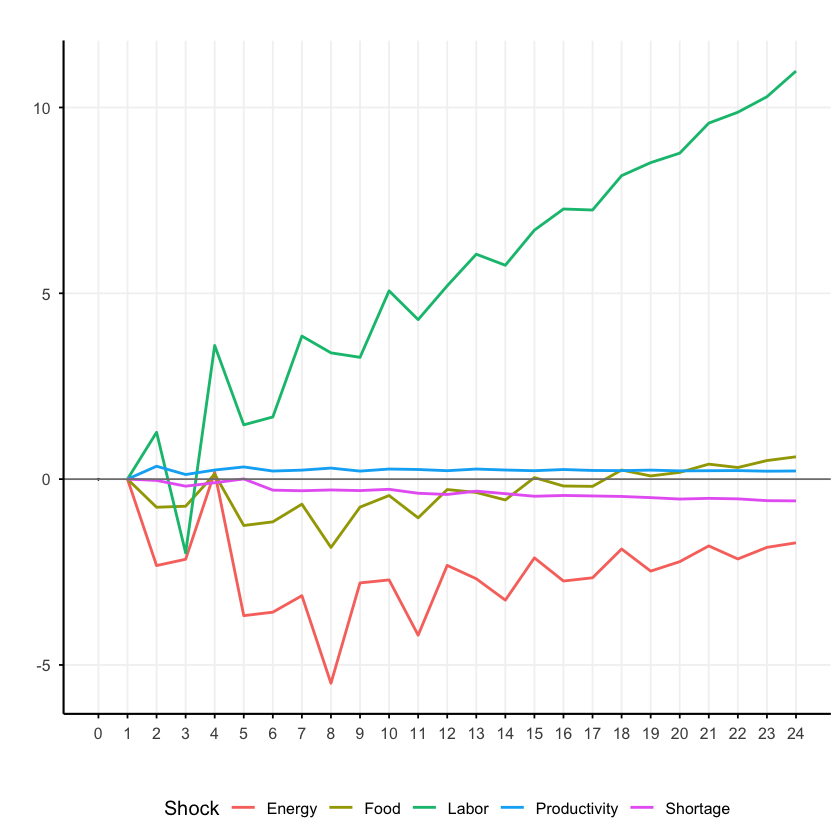

In [18]:
# 1. Příprava dat a aplikace transformace
plot_data_gw <- data.frame(period = 1:32)


plot_data_gw$Energy       <- cumsum(results_list$grpe$gw)
plot_data_gw$Food         <- cumsum(results_list$grpf$gw)
plot_data_gw$Labor        <- cumsum(results_list$vu$gw)
plot_data_gw$Shortage     <- cumsum(results_list$shortage$gw)
plot_data_gw$Productivity <- cumsum(results_list$gpty$gw)

# 2. Úprava tabulky a posun osy X (Lag 4 = 0)
plot_long_raw_gw <- plot_data_gw %>%
  mutate(x_axis = period - 4) %>%
  pivot_longer(cols = c(Energy, Food, Labor, Shortage, Productivity), 
               names_to = "Shock", 
               values_to = "Value") %>%
  filter(x_axis >= 0 & x_axis <= 24)

# 3. Vykreslení
p_gw <- ggplot(plot_long_raw_gw, aes(x = x_axis, y = Value, color = Shock)) +
  # Čára začíná od bodu 1 (Lag 5 - moment nárazu)
  geom_line(data = filter(plot_long_raw_gw, x_axis >= 1), size = 0.8) +
  
  # Bod 0,0 (Lag 4 - klid před bouří)
  geom_point(data = filter(plot_long_raw_gw, x_axis == 0), color = "black", size = 0) +
  
  # Nulová linka
  geom_hline(yintercept = 0, color = "gray50") +
  
  scale_x_continuous(breaks = 0:24) +
  
  labs(
    title = "",
    x = "",
    y = ""
  ) +
    theme_minimal() + 
    theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "gray95"),
    
    axis.line = element_line(color = "black", linewidth = 0.6), 
    axis.ticks = element_line(color = "black"),
    
    panel.border = element_blank(),
    panel.background = element_blank(),
    
    text = element_text(size = 12)
  )
p_gw

ggsave("irf_wage_cumulative.pdf", plot = p_gw, device = "pdf", 
       width = 8, height = 5, units = "in", dpi = 300)

# IRF CF1

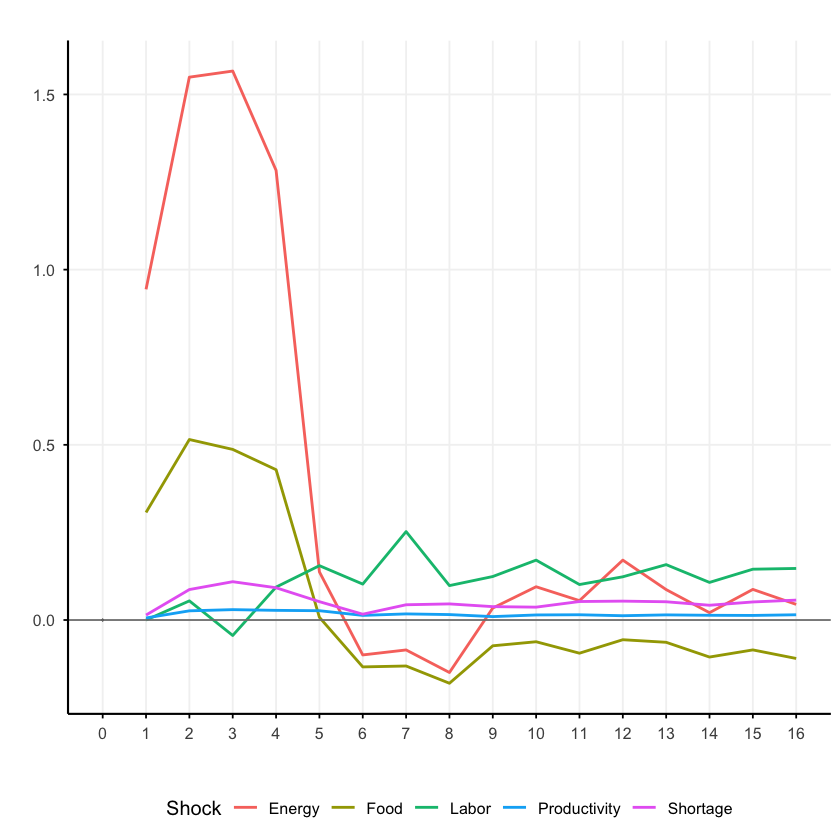

In [19]:
# 1. Příprava dat pro krátkodobá očekávání (plot_cf1)
plot_cf1 <- data.frame(period = 1:32)

plot_cf1$Energy       <- results_list$grpe$cf1
plot_cf1$Food         <- results_list$grpf$cf1
plot_cf1$Labor        <- results_list$vu$cf1
plot_cf1$Shortage     <- results_list$shortage$cf1
plot_cf1$Productivity <- results_list$gpty$cf1

# 2. Úprava tabulky a posun osy X (Lag 4 = 0)
plot_cf1_long <- plot_cf1 %>%
  mutate(x_axis = period - 4) %>%
  pivot_longer(cols = c(Energy, Food, Labor, Shortage, Productivity), 
               names_to = "Shock", 
               values_to = "Value") %>%
  filter(x_axis >= 0 & x_axis <= 16)

# 3. Vykreslení (bez vyhlazení - geom_line)
p_cf1 <- ggplot(plot_cf1_long, aes(x = x_axis, y = Value, color = Shock)) +
  # Čára začíná od bodu 1 (moment nárazu) a ukazuje syrovou reakci modelu
  geom_line(data = filter(plot_cf1_long, x_axis >= 1), size = 0.8) +
  
  # Bod 0,0 (Lag 4 - výchozí stabilní stav)
  geom_point(data = filter(plot_cf1_long, x_axis == 0), color = "black", size = 0) +
  
  # Nulová linka
  geom_hline(yintercept = 0, color = "gray50") +
  
  scale_x_continuous(breaks = 0:16) +
  
  labs(
    title = "",
    x = "",
    y = ""
  ) +
    theme_minimal() + 
    theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "gray95"),
    
    axis.line = element_line(color = "black", linewidth = 0.6), 
    axis.ticks = element_line(color = "black"),
    
    panel.border = element_blank(),
    panel.background = element_blank(),
    
    text = element_text(size = 12)
  )
p_cf1
ggsave("irf_cf1.pdf", plot = p_cf1, device = "pdf", 
       width = 8, height = 5, units = "in", dpi = 300)

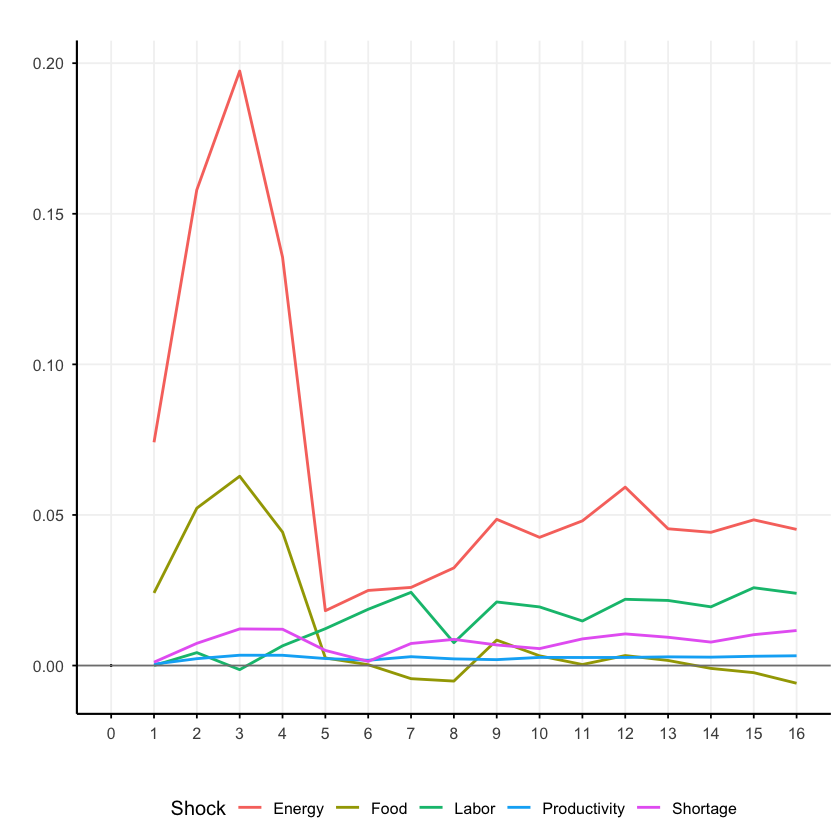

In [20]:
# 1. Příprava dat pro dlouhodobá očekávání (plot_cf10)
plot_cf10 <- data.frame(period = 1:32)

plot_cf10$Energy       <- results_list$grpe$cf10
plot_cf10$Food         <- results_list$grpf$cf10
plot_cf10$Labor        <- results_list$vu$cf10
plot_cf10$Shortage     <- results_list$shortage$cf10
plot_cf10$Productivity <- results_list$gpty$cf10

# 2. Úprava tabulky a posun osy X (Lag 4 = 0)
plot_cf10_long <- plot_cf10 %>%
  mutate(x_axis = period - 4) %>%
  pivot_longer(cols = c(Energy, Food, Labor, Shortage, Productivity), 
               names_to = "Shock", 
               values_to = "Value") %>%
  filter(x_axis >= 0 & x_axis <= 16)

# 3. Vykreslení (geom_line)
p_cf3 <- ggplot(plot_cf10_long, aes(x = x_axis, y = Value, color = Shock)) +
  # Čára reakce
  geom_line(data = filter(plot_cf10_long, x_axis >= 1), size = 0.8) +
  
  # Bod 0,0 (výchozí stav)
  geom_point(data = filter(plot_cf10_long, x_axis == 0), color = "black", size = 0) +
  
  # Nulová linka
  geom_hline(yintercept = 0, color = "gray50") +
  
  scale_x_continuous(breaks = 0:16) +
  
  labs(
    title = "",
    x = "",
    y = ""
  ) +
    theme_minimal() + 
    theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "gray95"),
    
    axis.line = element_line(color = "black", linewidth = 0.6), 
    axis.ticks = element_line(color = "black"),
    
    panel.border = element_blank(),
    panel.background = element_blank(),
    
    text = element_text(size = 12)
  )
p_cf3
ggsave("irf_cf3.pdf", plot = p_cf3, device = "pdf", 
       width = 8, height = 5, units = "in", dpi = 300)

## Decomposition

The decomposition is calculated in Matlab and graphs in python to copy the path of original paper.

In [117]:
# --- 1. residuals ---
df$res_gw   <- c(rep(0, 4), wage_model_restricted$residuals)
df$res_gcpi <- c(rep(0, 4), price_model_restricted$residuals)
df$res_cf1  <- c(rep(0, 4), cf1_model_restricted$residuals)
df$res_cf10 <- c(rep(0, 4), cf3_model_restricted$residuals) 

# %% 2. Format Data & Add Dummies / Residuals
df <- df %>%
  mutate(
    d_2020Q2 = ifelse(date == "2020Q2", 1, 0),
    d_2021Q1 = ifelse(date == "2021Q1", 1, 0),
    d_tariff = case_when(
      date == "2022Q4" ~ 1, 
      date == "2023Q1" ~ -1, 
      TRUE ~ 0
    )
  )

# --- 2. date formating ---
df <- df %>%
  mutate(
    period_date = as.Date(as.yearqtr(date, format = "%YQ%q")),
    period = format(period_date, "%m/%d/%Y")
  )

# --- 3. structure for MATLAB ---
data_to_export <- df %>%
  mutate(
  ) %>%
  select(
    period,
    gcpi, gw, 
    magpty = gpty, 
    grpe = grpe_cpi, 
    grpf = grpf_cpi, 
    vu, cf1, 
    cf10 = cf3, 
    shortage, 
    diffcpicf = diff_cpi, 
    gw_residuals = res_gw,
    gcpi_residuals = res_gcpi,
    cf1_residuals = res_cf1,
    cf10_residuals = res_cf10,
    # my additional wariables
    d_2020Q2, d_2021Q1, d_tariff
  )

# --- 4. EXPORT to EXCEL ---
write_xlsx(data_to_export, "eq_simulations_data.xlsx") 